In [33]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [34]:
dataset = pd.read_csv('E-commerece sales data 2024.csv')
df_customer = pd.read_csv('customer_details.csv')
df_product = pd.read_csv('product_details.csv')

In [35]:
dataset.columns

Index(['user id', 'product id', 'Interaction type', 'Time stamp',
       'Unnamed: 4'],
      dtype='object')

In [36]:
df_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3900 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [37]:
df_product.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10002 entries, 0 to 10001
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Uniqe Id               10002 non-null  object 
 1   Product Name           10002 non-null  object 
 2   Brand Name             0 non-null      float64
 3   Asin                   0 non-null      float64
 4   Category               9172 non-null   object 
 5   Upc Ean Code           34 non-null     object 
 6   List Price             0 non-null      float64
 7   Selling Price          9895 non-null   object 
 8   Quantity               0 non-null      float64
 9   Model Number           8230 non-null   object 
 10  About Product          9729 non-null   object 
 11  Product Specification  8370 non-null   object 
 12  Technical Details      9212 non-null   object 
 13  Shipping Weight        8864 non-null   object 
 14  Product Dimensions     479 non-null    object 
 15  Im

In [38]:
df_product.isnull().sum()

Uniqe Id                     0
Product Name                 0
Brand Name               10002
Asin                     10002
Category                   830
Upc Ean Code              9968
List Price               10002
Selling Price              107
Quantity                 10002
Model Number              1772
About Product              273
Product Specification     1632
Technical Details          790
Shipping Weight           1138
Product Dimensions        9523
Image                        0
Variants                  7524
Sku                      10002
Product Url                  0
Stock                    10002
Product Details          10002
Dimensions               10002
Color                    10002
Ingredients              10002
Direction To Use         10002
Is Amazon Seller             0
Size Quantity Variant    10002
Product Description      10002
dtype: int64

In [39]:
def cek_null(dfs):
    null_count = dfs.isnull().sum()
    null_columns= null_count[null_count>200].index.tolist()
    return null_columns
ctd = cek_null(df_product)
p = df_product.drop(ctd,axis=1)
p = p.drop(['Image','Product Url'],axis=1)
p = pd.concat([p, df_product[['Category']]],axis=1)
p = p.dropna()
df_product= p

In [40]:
dataset = dataset.drop(dataset.columns[-1],axis=1)
dataset = dataset.dropna()

In [41]:
print(f'Total Row: {dataset.shape[0]}, Total Shape: {dataset.shape[1]}')
print(f'Total duplicated data: {dataset.duplicated().sum()}')
print(f'Total NaN is: {dataset.isna().sum().sum()}')
print(f'Total NaN is: {dataset.isnull().sum().sum()}')

Total Row: 2871, Total Shape: 4
Total duplicated data: 0
Total NaN is: 0
Total NaN is: 0


In [42]:
print('Data Frame customer')
print(f'Total Row: {df_customer.shape[0]}, Total Shape: {df_customer.shape[1]}')
print(f'Total duplicated data: {df_customer.duplicated().sum()}')
print(f'Total NaN is: {df_customer.isna().sum().sum()}')
print(f'Total NaN is: {df_customer.isnull().sum().sum()}')

Data Frame customer
Total Row: 3900, Total Shape: 18
Total duplicated data: 0
Total NaN is: 0
Total NaN is: 0


In [43]:
print('Data Frame Product')
print(f'Total Row : {df_product.shape[0]}, Total Shape: {df_product.shape[1]}')
print(f'Total duplicated data: {df_product.duplicated().sum()}')
print(f'Total NaN is: {df_product.isna().sum().sum()}')
print(f'Total NaN is: {df_product.isnull().sum().sum()}')

Data Frame Product
Total Row : 9066, Total Shape: 5
Total duplicated data: 0
Total NaN is: 0
Total NaN is: 0


In [44]:
df_customer['Age Group'] = pd.cut(df_customer['Age'], bins=[0, 30, 40, 50, 60, 100], labels=['<30', '30-40', '40-50', '50-60', '60+'])
def segmentation (df, column):
    result= df.groupby(column).agg({
        'Customer ID': 'count',
        'Purchase Amount (USD)': 'mean',
        'Previous Purchases': 'sum'
    }).reset_index()
    return result
segmentation_Age = segmentation(df_customer,'Age Group')

In [45]:
segmentation_location = segmentation(df= df_customer,column='Location')
segmentation_location = segmentation_location.sort_values(by='Customer ID', ascending=False)
top_locations = segmentation_location.head(10)

In [46]:
p = pd.merge(dataset, df_product, left_on='product id', right_on='Uniqe Id')
p = p.drop(['Uniqe Id'],axis=1)
df_product1 = p
df_product1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2604 entries, 0 to 2603
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user id           2604 non-null   float64
 1   product id        2604 non-null   object 
 2   Interaction type  2604 non-null   object 
 3   Time stamp        2604 non-null   object 
 4   Product Name      2604 non-null   object 
 5   Selling Price     2604 non-null   object 
 6   Is Amazon Seller  2604 non-null   object 
 7   Category          2604 non-null   object 
dtypes: float64(1), object(7)
memory usage: 162.9+ KB


In [47]:
segmentation_Category = df_product1.groupby('Category').agg({
    'Selling Price' : 'sum',
    'user id' : 'count'
    }).reset_index()
segmentation_Category = segmentation_Category.sort_values(by='user id', ascending=False)
Top_Category = segmentation_Category.head(10)

Analisis data berdasarkan customer

Analysis

Segmentasi

In [48]:
df_product1['Selling Price']= df_product1['Selling Price'].str.replace('$','')

In [49]:
def convert_to_float_or_zero(value):
    try:
        return float(value)
    except ValueError:
        return 0.0

def convert_column_to_float(df, column_name):
    df[column_name] = df[column_name].apply(convert_to_float_or_zero)
    return df
convert_column_to_float(df_product1,'Selling Price')

,user id,product id,Interaction type,Time stamp,Product Name,Selling Price,Is Amazon Seller,Category
0,1.0,4c69b61db1fc16e7013b43fc926e502d,purchase,10/10/2023 8:00,"DB Longboards CoreFlex Crossbow 41"" Bamboo Fib...",237.68,Y,Sports & Outdoors | Outdoor Recreation | Skate...
1,2.0,66d49bbed043f5be260fa9f7fbff5957,view,11/10/2023 8:00,"Electronic Snap Circuits Mini Kits Classpack, ...",99.95,Y,Toys & Games | Learning & Education | Science ...
2,3.0,2c55cae269aebf53838484b0d7dd931a,like,12/10/2023 8:00,3Doodler Create Flexy 3D Printing Filament Ref...,34.99,Y,Toys & Games | Arts & Crafts | Craft Kits
3,4.0,18018b6bc416dab347b1b7db79994afa,view,13/10/2023 8:00,Guillow Airplane Design Studio with Travel Cas...,28.91,Y,Toys & Games | Hobbies | Models & Model Kits |...
4,5.0,e04b990e95bf73bbe6a3fa09785d7cd0,like,14/10/2023 8:00,Woodstock- Collage 500 pc Puzzle,17.49,Y,Toys & Games | Puzzles | Jigsaw Puzzles
...,...,...,...,...,...,...,...,...
2599,2995.0,f5149cfb8e04d7b30bd7b4eaed6713b8,like,15/12/2023 8:00,Bandito MT 2.8 1/10 RC Monster Truck Tires wit...,27.31,Y,Toys & Games | Hobbies | Remote & App Controll...
2600,2996.0,82318e8acf79bbeb3cf685a2732fb630,view,16/12/2023 8:00,Steiff Baby Teddy & Me Teddy Bear Boy with Paj...,45.95,Y,Toys & Games | Stuffed Animals & Plush Toys | ...
2601,2997.0,19d150365d798db47cccf1622b6ad754,purchase,17/12/2023 8:00,uxcell 1500 A12121200ux0003-10000RPM DC3-12V H...,5.33,Y,Toys & Games | Hobbies | Remote & App Controll...
2602,2998.0,136c0aff3ab56bd3d138775fe90ef970,view,18/12/2023 8:00,Zvezda 5023 - 1/72 German King Tiger Ausf B He...,14.90,Y,Toys & Games | Hobbies | Models & Model Kits |...


In [50]:
segmentation_Interaction = df_product1.groupby('Interaction type').agg({
    'Selling Price' : 'sum',
    'Category' : 'count'
    }).reset_index()

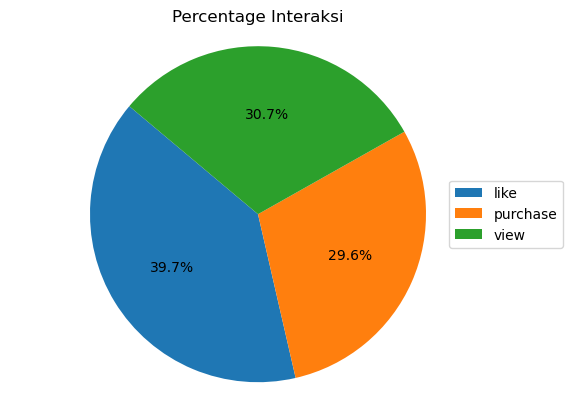

In [51]:
plt.pie(segmentation_Interaction['Category'],labels=None, autopct='%1.1f%%', startangle=140)
plt.axis('equal')
plt.title('Percentage Interaksi')
plt.legend(segmentation_Interaction['Interaction type'], loc='center', bbox_to_anchor=(1, 0.5))
plt.show()

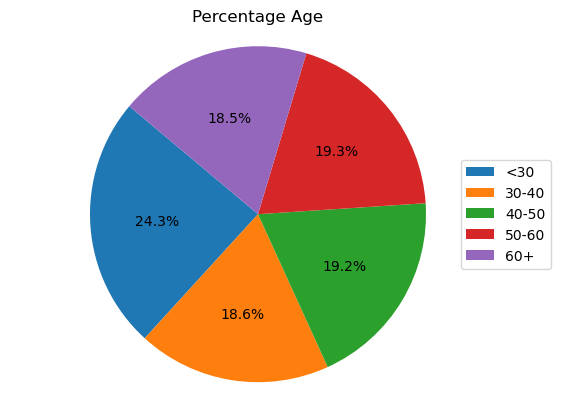

In [52]:
plt.pie(segmentation_Age['Customer ID'],labels=None, autopct='%1.1f%%', startangle=140)
plt.axis('equal')
plt.title('Percentage Age')
plt.legend(segmentation_Age['Age Group'], loc='center', bbox_to_anchor=(1, 0.5))
plt.show()

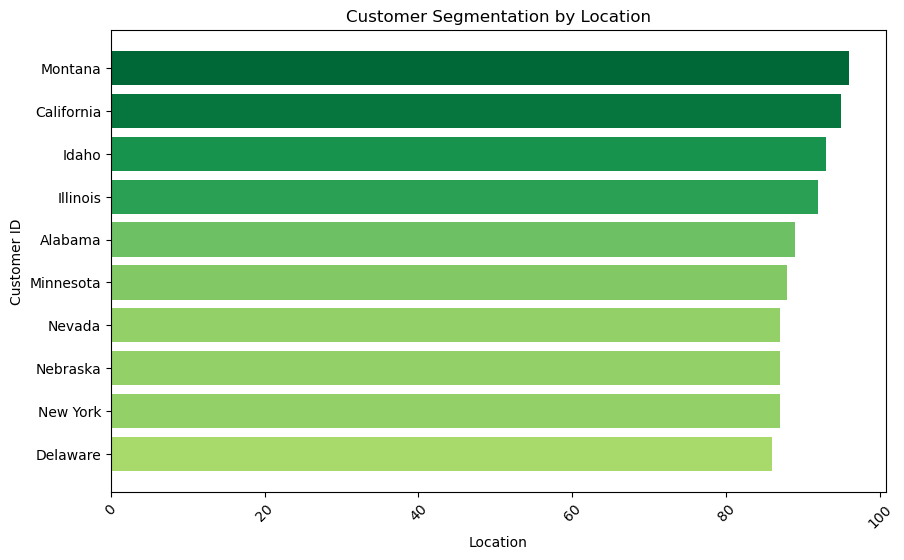

In [53]:
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
norm = Normalize(vmin=segmentation_location['Customer ID'].min(), vmax=segmentation_location['Customer ID'].max())
colors = plt.cm.RdYlGn(norm(segmentation_location['Customer ID']))
plt.figure(figsize=(10, 6))
plt.barh(top_locations['Location'],top_locations['Customer ID'], color=colors)
plt.xlabel('Location')
plt.ylabel('Customer ID')
plt.title('Customer Segmentation by Location')
sm = ScalarMappable(cmap=plt.cm.RdYlGn, norm=norm)
sm.set_array([])
plt.xticks(rotation=45)
plt.gca().invert_yaxis()
plt.show()

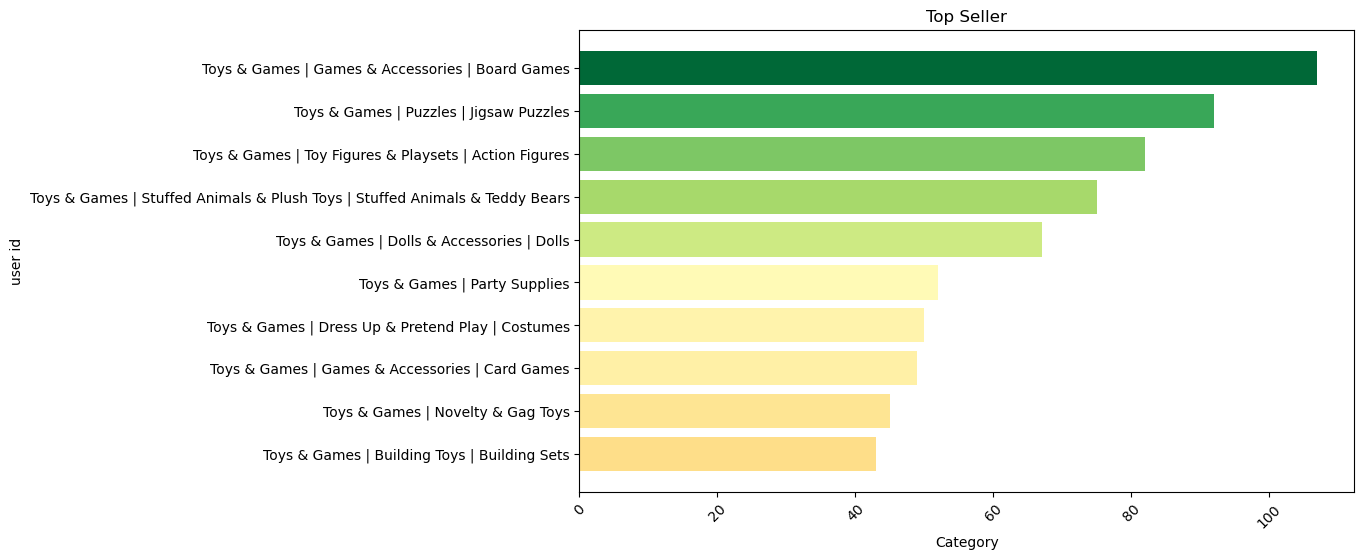

In [54]:
norm = Normalize(vmin=segmentation_Category['user id'].min(), vmax=segmentation_Category['user id'].max())
colors = plt.cm.RdYlGn(norm(segmentation_Category['user id']))
plt.figure(figsize=(10, 6))
plt.barh(Top_Category['Category'],Top_Category['user id'], color=colors)
plt.xlabel('Category')
plt.ylabel('user id')
plt.title('Top Seller')
sm = ScalarMappable(cmap=plt.cm.RdYlGn, norm=norm)
sm.set_array([])
plt.xticks(rotation=45)
plt.gca().invert_yaxis()
plt.show()